# XGBoost — Base 1

Este notebook executa o modelo de especialização XGBoost com validação temporal. Ele é autocontido e usa os caminhos canônicos `data/base_01/` e `notebooks/` da estrutura atual do projeto. A análise conceitual e comparativa das cinco bases está em `docs/modelo_xgboost.md`.

## Protocolo

- Mesmas features, origem, horizonte e corte de teste do Random Forest desta base.
- Alvo de um passo e persistência como referência.
- Busca aleatória em duas etapas: 120 configurações amplas e 30 refinadas.
- Três dobras expansivas com purga de alvos que alcançam a validação.
- Parâmetros congelados antes do teste final.
- Walk-forward expansivo, com somente alvos disponíveis em cada reajuste.
- Gain e Permutation Importance, resíduos, ACF e Ljung–Box.

Por padrão são avaliadas as 150 configurações. Para uma verificação rápida, defina a variável de ambiente `XGBOOST_SMOKE_TEST=1` antes de executar o notebook.


In [1]:
import hashlib
import itertools
import json
import math
import os
import platform
import tempfile
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import xgboost
from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from xgboost import XGBRegressor


def encontrar_raiz():
    atual = Path.cwd().resolve()
    for raiz in (atual, *atual.parents):
        if (raiz / "pyproject.toml").is_file() and (raiz / "data").is_dir():
            return raiz
    raise FileNotFoundError("Raiz do projeto não encontrada; execute dentro do repositório.")


ROOT = encontrar_raiz()
sys.path.insert(0, str(ROOT / "src"))
from series_temporais.reporting.residuos import salvar_residuos_nivel
from series_temporais.reporting.metricas_xgboost import atualizar_metricas_xgboost
from series_temporais.validation.checkpoints import assinatura_busca_temporal, codigo_metodologico
from series_temporais.reporting.importancias import importancia_temporal
SMOKE_TEST = os.getenv("XGBOOST_SMOKE_TEST", "0") == "1"
RUN_LABEL = "smoke" if SMOKE_TEST else "full"
N_ITER_AMPLA = 2 if SMOKE_TEST else 120
N_ITER_REFINADA = 1 if SMOKE_TEST else 30
N_SPLITS = 3
PERMUTATION_REPEATS = 1 if SMOKE_TEST else 3
PERMUTATION_MAX_ROWS = 200 if SMOKE_TEST else 500
IMPORTANCE_EVERY = 28
IMPORTANCE_WINDOW = 26
PROGRESS_EVERY = 1
XGBOOST_DEVICE = os.getenv("XGBOOST_DEVICE", "cpu")
TEMP_ROOT = Path(tempfile.gettempdir()) / "trabalho_daniel_xgboost"
SUMMARY_DIR = TEMP_ROOT / "summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
print("Raiz:", ROOT)
print("Modo:", "TESTE REDUZIDO" if SMOKE_TEST else "BUSCA COMPLETA (150 candidatos)")
print("XGBoost:", xgboost.__version__, "| dispositivo:", XGBOOST_DEVICE)


Raiz: C:\Users\giovannetorquato-ieg\OneDrive - Instituto J&F\Germinare\Terceiro Ano\Séries Temporais\Praticas\Trabalho XGBoost
Modo: BUSCA COMPLETA (150 candidatos)
XGBoost: 3.4.1 | dispositivo: cpu


In [2]:
BASE_NUMBER=1; BASE_NAME="Bitcoin diário"; DATA_PATH=ROOT/"data/base_01/prepared.csv"
TIME_COL="Date"; TARGET_COL="Close"; EXTERNAL_COLS=["Open","High","Low","Volume"]
EXPECTED_STEP=pd.Timedelta("1D"); FREQUENCY="D"; TRAIN_RATIO=.7; LAGS=[1,2,3,7,14,30]; WINDOWS=[7,14,30]
AVAILABILITY={c:("na_origem",0) for c in EXTERNAL_COLS}; TUNING_MAX_ROWS=None; EXPECTED_FEATURE_COUNT=23
RANDOM_STATE=42; LJUNG_LAGS=[1,7,14,30]; np.random.seed(RANDOM_STATE)


## Funcionamento e intuição

O XGBoost constrói árvores de decisão sequencialmente. Cada nova árvore aproxima o gradiente do erro deixado pelo conjunto anterior; a previsão final é a soma das contribuições das árvores. A regularização da complexidade das árvores, a contração por `learning_rate` e a amostragem de linhas e colunas reduzem sobreajuste.

O método não exige normalização das variáveis nem linearidade, mas pressupõe que o padrão aprendido do passado seja útil no futuro. Em séries temporais isso exige transformar a sequência em uma tabela causal: lags, janelas e estados externos precisam conter apenas informação disponível na origem da previsão.

### Hiperparâmetros principais

- `n_estimators`: quantidade de árvores; mais árvores elevam capacidade e custo.
- `learning_rate`: contribuição de cada árvore; valores menores normalmente exigem mais árvores.
- `max_depth` e `min_child_weight`: controlam complexidade e especialização das folhas.
- `subsample` e `colsample_bytree`: amostram linhas e features, adicionando regularização.
- `reg_alpha` e `reg_lambda`: penalizações L1 e L2.

A otimização abaixo usa apenas o treino. Gain mede a redução de perda atribuída às divisões de cada feature. Permutation Importance mede quanto o MAE piora ao embaralhar a feature em blocos fora da amostra. Nenhuma delas prova causalidade; features correlacionadas podem dividir ou deslocar importância.


In [3]:
GRADE_XGBOOST = {
    "n_estimators": (100, 200, 400, 800),
    "learning_rate": (0.02, 0.05, 0.10),
    "max_depth": (2, 3, 5, 7),
    "min_child_weight": (1, 5, 10),
    "subsample": (0.7, 0.9, 1.0),
    "colsample_bytree": (0.6, 0.8, 1.0),
    "reg_alpha": (0.0, 0.1),
    "reg_lambda": (1.0, 5.0),
}


def json_default(value):
    if isinstance(value, np.integer): return int(value)
    if isinstance(value, np.floating): return float(value)
    if isinstance(value, np.bool_): return bool(value)
    if isinstance(value, (pd.Timestamp, Path)): return str(value)
    raise TypeError(f"Tipo não serializável: {type(value)}")


def purged_time_series_splits(origin_time, target_time, n_splits=3):
    origens = pd.Series(pd.to_datetime(origin_time, errors="raise")).reset_index(drop=True)
    alvos = pd.Series(pd.to_datetime(target_time, errors="raise")).reset_index(drop=True)
    if len(origens) != len(alvos) or len(origens) < n_splits + 1:
        raise ValueError("Amostras insuficientes ou vetores temporais incompatíveis.")
    if origens.isna().any() or alvos.isna().any() or not origens.is_monotonic_increasing:
        raise ValueError("Datas inválidas ou fora de ordem.")
    if not alvos.gt(origens).all():
        raise ValueError("Cada alvo deve ser posterior à origem.")
    tamanho = len(origens) // (n_splits + 1)
    splits = []
    for dobra in range(n_splits):
        inicio = len(origens) - (n_splits - dobra) * tamanho
        fim = len(origens) if dobra == n_splits - 1 else inicio + tamanho
        validacao = np.arange(inicio, fim, dtype=int)
        ajuste = np.flatnonzero((np.arange(len(origens)) < inicio) & (alvos <= origens.iloc[inicio]))
        if not len(ajuste) or not len(validacao):
            raise ValueError("A purga produziu uma dobra vazia.")
        assert alvos.iloc[ajuste].max() <= origens.iloc[validacao].min()
        splits.append((ajuste, validacao))
    return splits


def chronological_train_test(quadro, train_ratio, origin_col, target_time_col):
    corte = int(len(quadro) * train_ratio)
    if corte <= 0 or corte >= len(quadro):
        raise ValueError("Corte temporal produz treino ou teste vazio.")
    inicio_teste = quadro.iloc[corte][origin_col]
    treino = quadro.iloc[:corte]
    treino = treino.loc[treino[target_time_col] <= inicio_teste].reset_index(drop=True)
    teste = quadro.iloc[corte:].reset_index(drop=True)
    if treino.empty or teste.empty:
        raise ValueError("Purga na fronteira produziu conjunto vazio.")
    assert treino[target_time_col].max() <= teste[origin_col].min()
    return treino, teste


def sample_grid(grade, n_iter, random_state):
    nomes = list(grade)
    combinacoes = [dict(zip(nomes, valores)) for valores in itertools.product(*(grade[n] for n in nomes))]
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(combinacoes), size=min(n_iter, len(combinacoes)), replace=False)
    return [combinacoes[int(i)] for i in indices]


def refined_grid(best):
    def ints(key, offsets, minimum=1):
        return tuple(sorted({max(minimum, int(best[key]) + d) for d in offsets}))
    def bounded(key, factors, minimum, maximum):
        return tuple(sorted({round(min(maximum, max(minimum, float(best[key]) * f)), 4) for f in factors}))
    return {
        "n_estimators": ints("n_estimators", (-100, -50, 0, 50, 100), 50),
        "learning_rate": bounded("learning_rate", (.5, .75, 1, 1.25, 1.5), .005, .3),
        "max_depth": ints("max_depth", (-2, -1, 0, 1, 2)),
        "min_child_weight": ints("min_child_weight", (-2, -1, 0, 1, 2)),
        "subsample": bounded("subsample", (.85, 1, 1.15), .5, 1),
        "colsample_bytree": bounded("colsample_bytree", (.85, 1, 1.15), .5, 1),
        "reg_alpha": tuple(sorted({0., round(float(best["reg_alpha"]) / 2, 4), float(best["reg_alpha"]), round(float(best["reg_alpha"]) * 2 + .05, 4)})),
        "reg_lambda": bounded("reg_lambda", (.5, .75, 1, 1.5, 2), .1, 20),
    }


def typed_params(params):
    saida = dict(params)
    for key in ("n_estimators", "max_depth", "min_child_weight"):
        saida[key] = int(saida[key])
    for key in ("learning_rate", "subsample", "colsample_bytree", "reg_alpha", "reg_lambda"):
        saida[key] = float(saida[key])
    return saida


def estimator_factory(params):
    kwargs = {
        **typed_params(params), "objective": "reg:squarederror", "random_state": RANDOM_STATE,
        "n_jobs": -1, "tree_method": "hist", "verbosity": 0,
    }
    if XGBOOST_DEVICE != "cpu":
        kwargs["device"] = XGBOOST_DEVICE
    return XGBRegressor(**kwargs)


def candidate_key(stage, params):
    payload = {"signature": RUN_SIGNATURE, "stage": stage, "params": typed_params(params)}
    return json.dumps(payload, sort_keys=True, ensure_ascii=False)


def temporal_search(quadro, grade, n_iter, stage, random_state):
    candidates = sample_grid(grade, n_iter, random_state)
    checkpoint = CHECKPOINT_DIR / f"search_{stage}.jsonl"
    registros = {}
    if checkpoint.exists():
        for line in checkpoint.read_text(encoding="utf-8").splitlines():
            try:
                row = json.loads(line)
                registros[row["candidate_key"]] = row
            except (json.JSONDecodeError, KeyError):
                continue
    splits = purged_time_series_splits(tuning_df[ORIGIN_COL], tuning_df[TARGET_TIME_COL], N_SPLITS)
    start_all = time.perf_counter()
    for candidate_id, params in enumerate(candidates, 1):
        key = candidate_key(stage, params)
        if key in registros:
            continue
        started = time.perf_counter()
        try:
            fold_mae = []
            for fit_idx, validation_idx in splits:
                model = estimator_factory(params)
                model.fit(quadro.iloc[fit_idx][FEATURES], quadro.iloc[fit_idx][MODEL_TARGET])
                pred = model.predict(quadro.iloc[validation_idx][FEATURES])
                fold_mae.append(mean_absolute_error(quadro.iloc[validation_idx][MODEL_TARGET], pred))
            row = {
                "candidate_key": key, "candidate_id": candidate_id, "stage": stage, "status": "ok",
                **typed_params(params), "mean_validation_mae": float(np.mean(fold_mae)),
                "std_validation_mae": float(np.std(fold_mae, ddof=1)),
                "fit_seconds": time.perf_counter() - started, "error": "",
            }
        except Exception as exc:
            row = {
                "candidate_key": key, "candidate_id": candidate_id, "stage": stage, "status": "erro",
                **typed_params(params), "mean_validation_mae": None, "std_validation_mae": None,
                "fit_seconds": time.perf_counter() - started, "error": str(exc),
            }
        with checkpoint.open("a", encoding="utf-8") as stream:
            stream.write(json.dumps(row, ensure_ascii=False, default=json_default) + "\n")
        registros[key] = row
        print(f"[{stage} {candidate_id:>3}/{len(candidates)}] status={row['status']} MAE={row['mean_validation_mae']} tempo={row['fit_seconds']:.2f}s")
    current_keys = {candidate_key(stage, p) for p in candidates}
    frame = pd.DataFrame([registros[k] for k in current_keys if k in registros])
    valid = frame.loc[frame.status.eq("ok")].sort_values(["mean_validation_mae", "std_validation_mae", "candidate_id"]).reset_index(drop=True)
    if valid.empty:
        raise RuntimeError(f"Nenhum candidato válido na etapa {stage}.")
    names = list(grade)
    best = typed_params({name: valid.iloc[0][name] for name in names})
    print(f"Etapa {stage}: {len(frame)} candidatos; tempo desta chamada={time.perf_counter()-start_all:.2f}s")
    return best, frame.sort_values(["status", "mean_validation_mae"], ascending=[False, True]).reset_index(drop=True)


def walk_forward(treino, teste, params, refit_every):
    if not isinstance(refit_every, int) or isinstance(refit_every, bool) or refit_every < 1: raise ValueError("Cadência inválida.")
    predictions, fits, importance = [], [], []
    evaluation_clock = time.perf_counter()
    progress_path = CHECKPOINT_DIR / f"evaluation_progress_refit_{refit_every}.json"
    progress_path.write_text(json.dumps({"completed": 0, "total": len(teste), "updated_at": str(pd.Timestamp.now(tz="UTC"))}), encoding="utf-8")
    for block_start in range(0, len(teste), refit_every):
        block_end = min(block_start + refit_every, len(teste))
        block = teste.iloc[block_start:block_end]
        refit_origin = block.iloc[0][ORIGIN_COL]
        history = pd.concat([treino, teste.loc[teste[TARGET_TIME_COL] <= refit_origin]], ignore_index=True)
        cutoff = history[TARGET_TIME_COL].max()
        assert cutoff <= refit_origin
        model = estimator_factory(params)
        started = time.perf_counter()
        model.fit(history[FEATURES], history[MODEL_TARGET])
        fit_seconds = time.perf_counter() - started
        values = np.asarray(model.predict(block[FEATURES]), dtype=float)
        if not np.isfinite(values).all():
            raise ValueError("Previsões não finitas.")
        for (_, row), value in zip(block.iterrows(), values):
            predictions.append({
                ORIGIN_COL: row[ORIGIN_COL], TARGET_TIME_COL: row[TARGET_TIME_COL],
                "y_true": row[MODEL_TARGET], "y_pred": float(value),
                "model_refit_origin": refit_origin, "training_target_cutoff": cutoff,
            })
        fits.append({
            "model_refit_origin": refit_origin, "training_target_cutoff": cutoff,
            "training_rows": len(history), "block_start": block_start,
            "block_end_exclusive": block_end, "fit_seconds": fit_seconds,
        })
        if block_start % IMPORTANCE_EVERY == 0:
            diagnostic = teste.iloc[block_start:min(block_start + IMPORTANCE_WINDOW, len(teste))]
            importance.extend(importancia_temporal(
                model, diagnostic, FEATURES, MODEL_TARGET, origin_col=ORIGIN_COL,
                training_cutoff=cutoff, refit_origin=refit_origin,
                n_repeats=PERMUTATION_REPEATS, seed=RANDOM_STATE,
            ))
        if len(fits) % PROGRESS_EVERY == 0 or block_end == len(teste):
            elapsed = time.perf_counter() - evaluation_clock
            remaining = elapsed / block_end * (len(teste) - block_end)
            progress_path.write_text(json.dumps({"completed": block_end, "total": len(teste), "elapsed_seconds": elapsed, "estimated_remaining_seconds": remaining, "updated_at": str(pd.Timestamp.now(tz="UTC"))}), encoding="utf-8")
            print(f"Walk-forward: {block_end}/{len(teste)} ({100*block_end/len(teste):.2f}%); tempo={elapsed/3600:.2f}h; restante estimado={remaining/3600:.2f}h", flush=True)
    return pd.DataFrame(predictions), pd.DataFrame(fits), pd.DataFrame(importance)


def level_metrics(real, predicted, level_t):
    real, predicted, level_t = map(lambda x: np.asarray(x, dtype=float), (real, predicted, level_t))
    return {
        "observacoes": len(real), "MAE": mean_absolute_error(real, predicted),
        "RMSE": mean_squared_error(real, predicted) ** .5,
        "MedAE": median_absolute_error(real, predicted), "R2": r2_score(real, predicted),
        "vies_medio": float(np.mean(real - predicted)),
        "acuracia_direcional": float(np.mean(np.sign(real-level_t) == np.sign(predicted-level_t))),
    }


def return_metrics(real_return, pred_return, price_t, real_price):
    real_return, pred_return, price_t, real_price = map(lambda x: np.asarray(x, dtype=float), (real_return, pred_return, price_t, real_price))
    pred_price = price_t * np.exp(pred_return)
    return {
        "observacoes": len(real_return), "MAE_retorno": mean_absolute_error(real_return, pred_return),
        "RMSE_retorno": mean_squared_error(real_return, pred_return) ** .5,
        "MedAE_retorno": median_absolute_error(real_return, pred_return),
        "R2_retorno": r2_score(real_return, pred_return),
        "vies_retorno": float(np.mean(real_return-pred_return)),
        "acuracia_direcional": float(np.mean(np.sign(real_return) == np.sign(pred_return))),
        "MAE_preco": mean_absolute_error(real_price, pred_price),
    }


In [4]:
def build_one_step_frame(dados):
    required = {TIME_COL, TARGET_COL, *EXTERNAL_COLS}
    missing = sorted(required.difference(dados.columns))
    if missing: raise KeyError(f"Colunas ausentes: {missing}")
    data = dados.copy()
    data[TIME_COL] = pd.to_datetime(data[TIME_COL], errors="raise")
    if data[TIME_COL].isna().any() or data[TIME_COL].duplicated().any() or not data[TIME_COL].is_monotonic_increasing:
        raise ValueError("Grade temporal inválida.")
    if not data[TIME_COL].diff().dropna().eq(EXPECTED_STEP).all():
        raise ValueError("A grade temporal precisa ser regular.")
    out = pd.DataFrame(index=data.index)
    out["origin_time"] = data[TIME_COL]
    out["target_time"] = data[TIME_COL].shift(-1)
    out["level_t"] = data[TARGET_COL]
    out["y_true"] = data[TARGET_COL].shift(-1)
    out["target_delta"] = out.y_true - out.level_t
    features = ["level_t"]
    for col in EXTERNAL_COLS:
        availability, lag = AVAILABILITY.get(col, ("na_origem", 0))
        if availability == "conhecido_antecipadamente":
            name, out_value = f"{col}_alvo", data[col].shift(-1)
        else:
            name, out_value = (f"{col}_t" if lag == 0 else f"{col}_lag_{lag}"), data[col].shift(lag)
        out[name] = out_value
        features.append(name)
    for lag in LAGS:
        name = f"target_lag_{lag}"; out[name] = data[TARGET_COL].shift(lag); features.append(name)
    prior = data[TARGET_COL].shift(1)
    for window in WINDOWS:
        roll = prior.rolling(window, min_periods=window)
        mean_name, std_name = f"target_mean_{window}", f"target_std_{window}"
        out[mean_name], out[std_name] = roll.mean(), roll.std(ddof=0)
        features.extend([mean_name, std_name])
    target_date = out.target_time
    for label, value, period in (("hour", target_date.dt.hour, 24), ("dow", target_date.dt.dayofweek, 7), ("month", target_date.dt.month-1, 12)):
        angle = 2*np.pi*value/period
        sin_name, cos_name = f"target_{label}_sin", f"target_{label}_cos"
        out[sin_name], out[cos_name] = np.sin(angle), np.cos(angle)
        features.extend([sin_name, cos_name])
    one_step = out.target_time.sub(out.origin_time).eq(EXPECTED_STEP)
    out = out.loc[one_step].dropna(subset=["origin_time", "target_time", "y_true", "target_delta", *features]).reset_index(drop=True)
    return out, features


raw = pd.read_csv(DATA_PATH, low_memory=False)
raw[TIME_COL] = pd.to_datetime(raw[TIME_COL], errors="raise")
raw = raw.sort_values(TIME_COL, kind="stable").reset_index(drop=True)
if BASE_NUMBER == 2:
    raw["is_holiday"] = raw["holiday"].notna().astype(int)
model_df, FEATURES = build_one_step_frame(raw)
assert len(FEATURES) == EXPECTED_FEATURE_COUNT, (len(FEATURES), EXPECTED_FEATURE_COUNT)
ORIGIN_COL, TARGET_TIME_COL, MODEL_TARGET = "origin_time", "target_time", "target_delta"
train_df, test_df = chronological_train_test(model_df, TRAIN_RATIO, ORIGIN_COL, TARGET_TIME_COL)
tuning_df = train_df.tail(TUNING_MAX_ROWS).reset_index(drop=True) if TUNING_MAX_ROWS else train_df
assert model_df[ORIGIN_COL].is_monotonic_increasing
assert np.isfinite(model_df[FEATURES].to_numpy(dtype=float)).all()
DATA_SHA256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
# Cache v2: somente tuning; mudanças de alvo/dados/lógica não reutilizam a busca antiga.
CODIGO_METODOLOGICO = codigo_metodologico(
    ROOT / 'notebooks' / f'base_{BASE_NUMBER:02d}-grupo{BASE_NUMBER}_XGBoost.ipynb',
    funcoes=['chronological_train_test', 'purged_time_series_splits', 'sample_grid', 'refined_grid', 'typed_params', 'estimator_factory', 'candidate_key', 'temporal_search', 'build_one_step_frame'],
    arquivos=[],
)
RUN_SIGNATURE = assinatura_busca_temporal(
    tuning_df, features=FEATURES, alvo=MODEL_TARGET,
    origem=ORIGIN_COL, instante_alvo=TARGET_TIME_COL,
    protocolo={
        'seed': RANDOM_STATE, 'n_splits': N_SPLITS, 'mode': RUN_LABEL,
        'frequency': FREQUENCY, 'horizon': 1, 'availability': AVAILABILITY,
        'scoring': 'neg_mean_absolute_error', 'objective': 'reg:squarederror',
        'device': XGBOOST_DEVICE, 'tree_method': 'hist',
        'xgboost': xgboost.__version__, 'sklearn': sklearn.__version__,
        'pandas': pd.__version__, 'numpy': np.__version__,
    },
    codigo=CODIGO_METODOLOGICO,
)
CHECKPOINT_DIR = TEMP_ROOT / f"grupo{BASE_NUMBER}" / RUN_LABEL / RUN_SIGNATURE[:12]
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame({"recorte": ["treino", "tuning", "teste"], "linhas": [len(train_df), len(tuning_df), len(test_df)]}))
print("Features:", len(FEATURES), "| teste:", test_df[ORIGIN_COL].min(), "→", test_df[ORIGIN_COL].max())
print("Checkpoints:", CHECKPOINT_DIR)


,recorte,linhas
0,treino,1963
1,tuning,1963
2,teste,842


Features: 23 | teste: 2022-06-17 00:00:00 → 2024-10-05 00:00:00
Checkpoints: C:\Users\GIOVAN~1\AppData\Local\Temp\trabalho_daniel_xgboost\grupo1\full\94595ee6ed6f


## Otimização temporal

A busca ampla explora regiões distintas; a etapa refinada amostra uma vizinhança do melhor candidato amplo. O ranking usa somente MAE de validação nas três dobras purgadas.


In [5]:
best_broad, broad_results = temporal_search(tuning_df, GRADE_XGBOOST, N_ITER_AMPLA, "ampla", RANDOM_STATE)
best_refined, refined_results = temporal_search(tuning_df, refined_grid(best_broad), N_ITER_REFINADA, "refinada", RANDOM_STATE + 1)
search_results = pd.concat([broad_results, refined_results], ignore_index=True)
valid_results = search_results.loc[search_results.status.eq("ok")].sort_values(["mean_validation_mae", "std_validation_mae", "candidate_id"]).reset_index(drop=True)
param_names = list(GRADE_XGBOOST)
best_params = typed_params({name: valid_results.iloc[0][name] for name in param_names})
FROZEN_PARAMS = json.dumps(best_params, sort_keys=True, default=json_default)
assert len(search_results) == N_ITER_AMPLA + N_ITER_REFINADA
print("Configuração congelada antes do teste:", FROZEN_PARAMS)
display(valid_results.head(15))


[ampla   1/120] status=ok MAE=1017.0292568365682 tempo=6.10s


[ampla   2/120] status=ok MAE=902.4304252391365 tempo=2.47s


[ampla   3/120] status=ok MAE=644.972078927804 tempo=1.12s


[ampla   4/120] status=ok MAE=796.4558154549222 tempo=4.44s


[ampla   5/120] status=ok MAE=724.4428023979068 tempo=1.61s


...

[refinada  27/30] status=ok MAE=657.7031806048893 tempo=1.07s


[refinada  28/30] status=ok MAE=645.2210212815579 tempo=0.65s


[refinada  29/30] status=ok MAE=613.3788638234341 tempo=1.50s


[refinada  30/30] status=ok MAE=617.9461238117572 tempo=1.84s
Etapa refinada: 30 candidatos; tempo desta chamada=43.67s
Configuração congelada antes do teste: {"colsample_bytree": 0.85, "learning_rate": 0.01, "max_depth": 9, "min_child_weight": 2, "n_estimators": 50, "reg_alpha": 0.1, "reg_lambda": 10.0, "subsample": 0.765}


,candidate_key,candidate_id,stage,status,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,mean_validation_mae,std_validation_mae,fit_seconds,error
0,"{""params"": {""colsample_bytree"": 0.85, ""learnin...",5,refinada,ok,50,0.010,9,2,0.765,0.85,0.10,10.00,597.555170,580.689785,0.803177,
1,"{""params"": {""colsample_bytree"": 0.85, ""learnin...",6,refinada,ok,50,0.010,7,1,0.765,0.85,0.00,2.50,600.068446,582.481241,0.595848,
2,"{""params"": {""colsample_bytree"": 0.85, ""learnin...",16,refinada,ok,100,0.010,6,2,0.765,0.85,0.05,10.00,602.679592,580.073600,0.992641,
3,"{""params"": {""colsample_bytree"": 0.85, ""learnin...",17,refinada,ok,100,0.010,7,2,0.765,0.85,0.10,7.50,604.344675,580.852160,1.181500,
4,"{""params"": {""colsample_bytree"": 1.0, ""learning...",18,refinada,ok,100,0.010,7,3,0.900,1.00,0.05,10.00,607.058357,579.814078,1.189460,
5,"{""params"": {""colsample_bytree"": 0.85, ""learnin...",12,refinada,ok,50,0.020,9,3,0.765,0.85,0.25,7.50,609.225649,584.995739,0.724962,
6,"{""params"": {""colsample_bytree"": 0.85, ""learnin...",29,refinada,ok,150,0.010,5,2,0.900,0.85,0.25,5.00,613.378864,588.282160,1.496238,
7,"{""params"": {""colsample_bytree"": 0.85, ""learnin...",30,refinada,ok,200,0.010,5,1,0.900,0.85,0.10,5.00,617.946124,591.437862,1.836006,
8,"{""params"": {""colsample_bytree"": 1.0, ""learning...",1,refinada,ok,150,0.025,5,1,0.900,1.00,0.00,10.00,620.830865,587.166028,1.462289,
9,"{""params"": {""colsample_bytree"": 1.0, ""learning...",21,refinada,ok,100,0.010,7,3,0.900,1.00,0.05,3.75,621.644454,594.380095,1.067710,


## Teste final walk-forward

A configuração acima é congelada. Em cada reajuste, entram apenas observações cujo alvo já ocorreu antes da origem do bloco previsto.


In [6]:
# Protocolo periódico: saídas antigas exigem reexecução; previsão segue em todas as origens.
REFIT_EVERY = 7
evaluation_start = time.perf_counter()
core_predictions, fit_log, importance_long = walk_forward(train_df, test_df, best_params, REFIT_EVERY)
assert len(fit_log) == math.ceil(len(test_df) / REFIT_EVERY)
assert (core_predictions.training_target_cutoff <= core_predictions.model_refit_origin).all()
print(f"Cadência: {REFIT_EVERY} origens; reajustes: {len(fit_log)}; previsões: {len(core_predictions)}")
evaluation_seconds = time.perf_counter() - evaluation_start
assert json.dumps(best_params, sort_keys=True, default=json_default) == FROZEN_PARAMS
assert len(core_predictions) == len(test_df)
assert core_predictions[ORIGIN_COL].reset_index(drop=True).equals(test_df[ORIGIN_COL].reset_index(drop=True))
assert (core_predictions.training_target_cutoff <= core_predictions[ORIGIN_COL]).all()
predictions = test_df[[ORIGIN_COL, TARGET_TIME_COL, "level_t", "y_true", MODEL_TARGET]].copy()
predictions["y_pred_delta_xgb"] = core_predictions.y_pred.to_numpy()
predictions["y_pred_xgb"] = predictions.level_t + predictions.y_pred_delta_xgb
predictions["y_pred_persistencia"] = predictions.level_t
predictions["residuo_xgb"] = predictions.y_true - predictions.y_pred_xgb
predictions["model_refit_origin"] = core_predictions.model_refit_origin.to_numpy()
predictions["training_target_cutoff"] = core_predictions.training_target_cutoff.to_numpy()
assert np.isfinite(predictions[["y_pred_delta_xgb", "y_pred_xgb"]]).all().all()
metrics = pd.DataFrame([
    {"modelo": "XGBoost", **level_metrics(predictions.y_true, predictions.y_pred_xgb, predictions.level_t)},
    {"modelo": "Persistência", **level_metrics(predictions.y_true, predictions.y_pred_persistencia, predictions.level_t)},
])
baseline_mae = metrics.loc[metrics.modelo.eq("Persistência"), "MAE"].iloc[0]
metrics["skill_MAE_vs_persistencia"] = 1 - metrics.MAE / baseline_mae


Walk-forward: 7/842 (0.83%); tempo=0.00h; restante estimado=0.02h


Walk-forward: 14/842 (1.66%); tempo=0.00h; restante estimado=0.02h


Walk-forward: 21/842 (2.49%); tempo=0.00h; restante estimado=0.02h


Walk-forward: 28/842 (3.33%); tempo=0.00h; restante estimado=0.01h


Walk-forward: 35/842 (4.16%); tempo=0.00h; restante estimado=0.02h


...

Walk-forward: 826/842 (98.10%); tempo=0.02h; restante estimado=0.00h


Walk-forward: 833/842 (98.93%); tempo=0.02h; restante estimado=0.00h


Walk-forward: 840/842 (99.76%); tempo=0.02h; restante estimado=0.00h


Walk-forward: 842/842 (100.00%); tempo=0.02h; restante estimado=0.00h


Cadência: 7 origens; reajustes: 121; previsões: 842


Resíduos individuais completos: C:\Users\giovannetorquato-ieg\OneDrive - Instituto J&F\Germinare\Terceiro Ano\Séries Temporais\Praticas\Trabalho XGBoost\results\residuals\base_01_XGBoost.csv


,origin_time,target_time,level_t,y_true,target_delta,y_pred_delta_xgb,y_pred_xgb,y_pred_persistencia,residuo_xgb,model_refit_origin,training_target_cutoff
0,2022-06-17,2022-06-18,20471.482422,19017.642578,-1453.839844,-31.056200,20440.426222,20471.482422,-1422.783644,2022-06-17,2022-06-17
1,2022-06-18,2022-06-19,19017.642578,20553.271484,1535.628906,33.227943,19050.870522,19017.642578,1502.400963,2022-06-17,2022-06-17
2,2022-06-19,2022-06-20,20553.271484,20599.537109,46.265625,26.942465,20580.213949,20553.271484,19.323160,2022-06-17,2022-06-17
3,2022-06-20,2022-06-21,20599.537109,20710.597656,111.060547,13.565924,20613.103033,20599.537109,97.494623,2022-06-17,2022-06-17
4,2022-06-21,2022-06-22,20710.597656,19987.029297,-723.568359,-18.702971,20691.894686,20710.597656,-704.865389,2022-06-17,2022-06-17
5,2022-06-22,2022-06-23,19987.029297,21085.876953,1098.847656,-21.925562,19965.103735,19987.029297,1120.773218,2022-06-17,2022-06-17
6,2022-06-23,2022-06-24,21085.876953,21231.656250,145.779297,34.047791,21119.924744,21085.876953,111.731506,2022-06-17,2022-06-17
7,2022-06-24,2022-06-25,21231.656250,21502.337891,270.681641,65.861183,21297.517433,21231.656250,204.820457,2022-06-24,2022-06-24
8,2022-06-25,2022-06-26,21502.337891,21027.294922,-475.042969,77.469963,21579.807854,21502.337891,-552.512932,2022-06-24,2022-06-24
9,2022-06-26,2022-06-27,21027.294922,20735.478516,-291.816406,24.786806,21052.081728,21027.294922,-316.603212,2022-06-24,2022-06-24


,modelo,observacoes,MAE,RMSE,MedAE,R2,vies_medio,acuracia_direcional,skill_MAE_vs_persistencia
0,XGBoost,842,694.167293,1119.148056,381.963964,0.996047,54.403486,0.503563,-0.001058
1,Persistência,842,693.433902,1117.845413,385.301758,0.996056,50.293908,0.000000,0.000000


,lag,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
0,1,5.475513,0.019285,True
1,7,13.657884,0.057612,False
2,14,32.225019,0.003721,True
3,30,71.339140,0.000032,True


,feature,gain_mean,gain_std,permutation_mean,permutation_std
0,target_std_7,0.061507,0.003860,0.644286,11.359931
1,target_lag_30,0.060504,0.004339,0.253623,2.678898
2,target_mean_30,0.056911,0.004606,-0.041638,1.172564
3,target_mean_14,0.055657,0.005590,0.020832,1.277697
4,target_lag_1,0.054848,0.008090,-0.084569,0.747552
5,target_std_14,0.054314,0.003290,1.450604,4.029465
6,target_std_30,0.054133,0.003562,0.394582,3.424054
7,Low_t,0.051875,0.006646,0.353650,1.979921
8,target_lag_2,0.047556,0.004858,-0.219699,2.220849
9,target_mean_7,0.047093,0.008342,-0.321285,1.531238


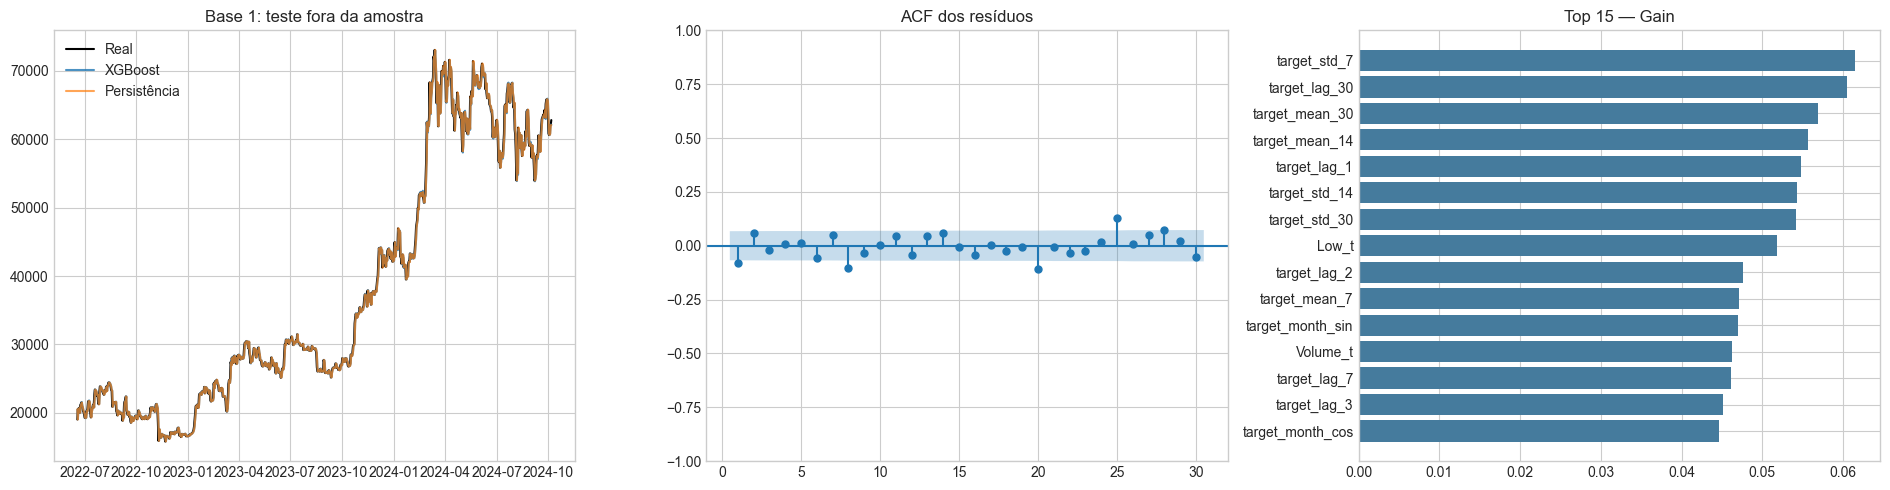

In [7]:
residual_file = salvar_residuos_nivel(predictions, ROOT, BASE_NUMBER, expected_rows=len(test_df), smoke=SMOKE_TEST)
print("Resíduos individuais completos:", residual_file)
display(predictions.head(20))
residual_col = "residual_return_xgb" if BASE_NUMBER == 5 else "residuo_xgb"
residuals = predictions[residual_col].dropna()
configured_lags = LJUNG_LAGS
usable_lags = [lag for lag in configured_lags if lag < len(residuals)]
ljung_box = acorr_ljungbox(residuals, lags=usable_lags, return_df=True).reset_index(names="lag")
ljung_box["rejeita_ruido_branco_5pct"] = ljung_box.lb_pvalue < .05
importance = importance_long.groupby("feature", as_index=False).agg(
    gain_mean=("gain", "mean"), gain_std=("gain", "std"),
    permutation_mean=("permutation_mean", "mean"), permutation_std=("permutation_mean", "std"),
).sort_values("gain_mean", ascending=False).reset_index(drop=True)

display(metrics)
display(ljung_box)
display(importance.head(20))
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
if BASE_NUMBER == 5:
    axes[0].plot(predictions.target_date, predictions.target_price_t_plus_1, label="Real", color="black")
    axes[0].plot(predictions.target_date, predictions.price_pred_xgb, label="XGBoost", alpha=.8)
    axes[0].plot(predictions.target_date, predictions.price_pred_persistencia, label="Persistência", alpha=.7)
else:
    axes[0].plot(predictions[TARGET_TIME_COL], predictions.y_true, label="Real", color="black")
    axes[0].plot(predictions[TARGET_TIME_COL], predictions.y_pred_xgb, label="XGBoost", alpha=.8)
    axes[0].plot(predictions[TARGET_TIME_COL], predictions.y_pred_persistencia, label="Persistência", alpha=.7)
axes[0].set_title(f"Base {BASE_NUMBER}: teste fora da amostra"); axes[0].legend()
plot_acf(residuals, lags=min(max(usable_lags), len(residuals)//2-1), zero=False, ax=axes[1], title="ACF dos resíduos")
top = importance.head(15).sort_values("gain_mean")
axes[2].barh(top.feature, top.gain_mean, color="#457b9d"); axes[2].set_title("Top 15 — Gain")
plt.tight_layout(); plt.show()


In [8]:
summary = {
    "base": BASE_NUMBER, "nome": BASE_NAME, "frequencia": FREQUENCY,
    "alvo": TARGET_COL, "observacoes_teste": len(test_df), "features": len(FEATURES),
    "mae_xgboost": float(metrics.loc[metrics.modelo.eq("XGBoost"), "MAE"].iloc[0]),
    "mae_persistencia": float(metrics.loc[metrics.modelo.eq("Persistência"), "MAE"].iloc[0]),
    "skill_vs_persistencia": float(metrics.loc[metrics.modelo.eq("XGBoost"), "skill_MAE_vs_persistencia"].iloc[0]),
    "best_params": best_params, "data_sha256": DATA_SHA256,
    "search_candidates": len(search_results), "refits": len(fit_log),
    "search_seconds_recorded": float(search_results.fit_seconds.sum()), "evaluation_seconds": evaluation_seconds,
}
(SUMMARY_DIR / f"base{BASE_NUMBER}.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=json_default), encoding="utf-8")
experiment_record = pd.DataFrame([{
    **summary, "features_list": json.dumps(FEATURES, ensure_ascii=False),
    "python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__,
    "scikit_learn": sklearn.__version__, "statsmodels": statsmodels.__version__, "xgboost": xgboost.__version__,
    "checkpoint_dir": str(CHECKPOINT_DIR),
}])
display(experiment_record.T)
if not SMOKE_TEST:
    atualizar_metricas_xgboost(ROOT, [summary])
    print("Métricas consolidadas: results/metrics.csv")
display(fit_log)


,0
base,1
nome,Bitcoin diário
frequencia,D
alvo,Close
observacoes_teste,842
features,23
mae_xgboost,694.167293
mae_persistencia,693.433902
skill_vs_persistencia,-0.001058
best_params,"{'n_estimators': 50, 'learning_rate': 0.01, 'm..."


,model_refit_origin,training_target_cutoff,training_rows,block_start,block_end_exclusive,fit_seconds
0,2022-06-17,2022-06-17,1963,0,7,0.293215
1,2022-06-24,2022-06-24,1970,7,14,0.336821
2,2022-07-01,2022-07-01,1977,14,21,0.364414
3,2022-07-08,2022-07-08,1984,21,28,0.308751
4,2022-07-15,2022-07-15,1991,28,35,0.313963
...,...,...,...,...,...,...
116,2024-09-06,2024-09-06,2775,812,819,0.328461
117,2024-09-13,2024-09-13,2782,819,826,0.318059
118,2024-09-20,2024-09-20,2789,826,833,0.323003
119,2024-09-27,2024-09-27,2796,833,840,0.344498


## Interpretação, limitações e pontos de atenção

O desempenho deve ser interpretado contra a persistência e dentro da escala desta base. Um ganho pequeno ou negativo indica que as relações não lineares aprendidas não compensaram a força do último valor observado. Diferenças entre bases podem vir da frequência, quantidade de treino, força de autocorrelação, ruído, mudanças de regime e qualidade ou disponibilidade das covariáveis externas.

O XGBoost não modela tempo automaticamente: toda estrutura temporal vem das features. Gain e Permutation Importance são descritivas, não causais. Na Base 5, as duas taxas externas permanecem provisórias e exigem homologação de fonte, unidade e disponibilidade. Horizonte, origens e teste continuam espelhados do RF até homologação definitiva do protocolo comum.

Os checkpoints e resumos ficam no diretório temporário. Todas as previsões e resíduos são exportados por código em `results/residuals/base_01_XGBoost.csv`, ignorado pelo Git; o modo reduzido usa o sufixo `_smoke`. As saídas anteriores à inclusão da exportação não geraram esse CSV.


## Resíduos XGBoost ao longo do tempo

Cada ponto é `real - previsto`, posicionado na data do alvo; positivo indica
subestimação e negativo, superestimação. A linha tracejada marca erro zero.
A escala é a unidade original do alvo desta base.
Não há interpolação: lacunas de calendário interrompem a linha. Todos os resíduos
são utilizados, sem amostragem ou seleção pelos valores dos erros.

Esta célula pode ser executada sozinha, em kernel novo, lendo o CSV completo local
e conferindo sua quantidade e MAE com `results/metrics.csv`. Em execução integral,
usa `predictions` em memória. Não treina modelos nem altera métricas. Os CSVs são
ignorados pelo Git; a figura fica incorporada à saída deste notebook. ACF permanece
um diagnóstico distinto de autocorrelação.


{
  "base_id": "base_01",
  "origens_avaliadas": 842,
  "mae": 694.1672931834524,
  "frequencia": "D",
  "inicio_alvo": "2022-06-18 00:00:00",
  "fim_alvo": "2024-10-06 00:00:00",
  "lacunas_no_tracado": 0,
  "residuo": "real - previsto",
  "fonte": "results\\residuals\\base_01_XGBoost.csv",
  "csv_sha256": "f23981c93a65ed526f11bd5f89fc6a01905be8691deab754bd09e2a0da3bb4a1",
  "modo": "full",
  "alvo": "Close"
}


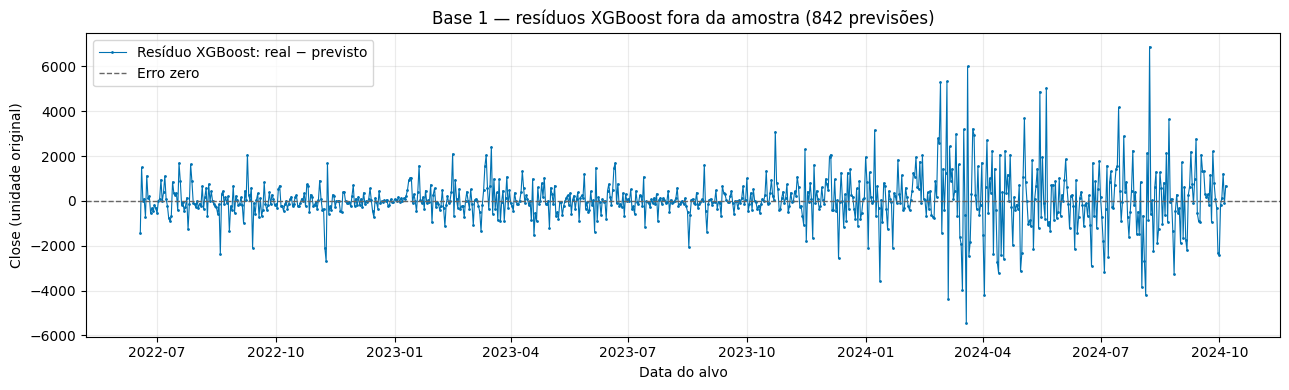

In [1]:
# Diagnóstico isolado: não executa tuning nem walk-forward.
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
_cwd_residuos = Path.cwd().resolve()
_raiz_residuos = next(
    (p for p in (_cwd_residuos, *_cwd_residuos.parents)
     if (p / "pyproject.toml").is_file() and (p / "data").is_dir()), None)
if _raiz_residuos is None:
    raise FileNotFoundError("Execute dentro do repositório.")
if str(_raiz_residuos / "src") not in sys.path:
    sys.path.insert(0, str(_raiz_residuos / "src"))
from series_temporais.reporting.residuos import grafico_residuos_xgboost
_fig_residuos, _audit_residuos = grafico_residuos_xgboost(
    _raiz_residuos, 1, predictions=globals().get("predictions"),
    smoke=bool(globals().get("SMOKE_TEST", False)))
print(json.dumps(_audit_residuos, ensure_ascii=False, indent=2))
plt.show()


## Justificativa das escolhas — XGBoost

O modelo usa features temporais causais compatíveis com RF para representar memória,
volatilidade e calendário. Nas Bases 1–4 aprende a mudança do nível, avaliada na unidade
original; na Base 5 aprende retorno logarítmico, com preço como conversão auxiliar.
Busca reproduzível de 150 candidatos em três dobras expansivas purgadas seleciona
parâmetros somente no treino; não prova ótimo global. A configuração é congelada no teste.

Nesta base, reajuste a cada **7 origens avaliáveis** torna o custo viável: cada origem
continua recebendo previsão de um passo com features atuais. Não é previsão multietapas
em bloco; as árvores ficam fixas entre ajustes. A cadência é operacional, não escolhida
pelo erro do teste nem comprovadamente ótima, e pode atrasar adaptação a mudanças.

Essas escolhas justificam o pipeline XGBoost, não as diferenças de amostra entre famílias.
O ponto 1 da revisão continua pendente: não declarar ranking geral com MAEs de testes
diferentes. Perder para persistência deve ser reportado, sem trocar o recorte para vencer.
Gain e Permutation Importance não provam causalidade. Ver
[justificativas e roteiro](../docs/justificativas_xgboost.md).
